In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType


## Set up PySpark Session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 15:10:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/18 15:10:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/18 15:10:24 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/18 15:10:24 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


## Directories

In [3]:
bronze_lms_directory = "datalake/bronze/lms/"
bronze_fin_directory = "datalake/bronze/financial/"
bronze_attr_directory = "datalake/bronze/attributes/"
bronze_click_directory = "datalake/bronze/clickstream/"

# Attributes EDA

In [4]:
# Load all bronze attributes CSVs at once and process
all_attr_files = glob.glob(os.path.join(bronze_attr_directory, '*.csv'))
df = spark.read.csv(all_attr_files, header=True, inferSchema=True)
print(f"loaded {len(all_attr_files)} files, total row count: {df.count()}")

column_type_map = {
    "Customer_ID": StringType(),
    "Name": StringType(),
    "Age": IntegerType(),
    "SSN": StringType(),
    "Occupation": StringType(),
    "snapshot_date": DateType()
}

numeric_cols = [(c, t) for c, t in column_type_map.items() if isinstance(t, (FloatType, IntegerType))]
for column, col_type in numeric_cols:
    df = df.withColumn(column, F.regexp_replace(col(column).cast(StringType()), "_", ""))

for column, new_type in column_type_map.items():
    df = df.withColumn(column, col(column).cast(new_type))

loaded 24 files, total row count: 11974


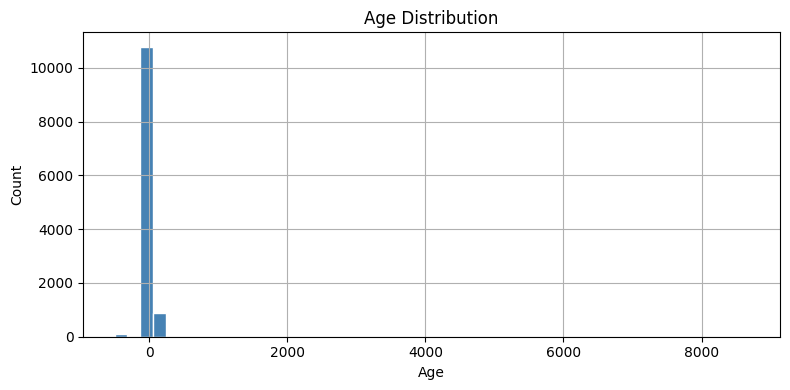

In [5]:
age_pdf = df.toPandas()

plt.figure(figsize=(8, 4))
plt.hist(age_pdf["Age"], bins=50, color="steelblue", edgecolor="white")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
df.toPandas()

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x10ac,Zhouy,29,780-50-4730,Developer,2024-08-01
1,CUS_0x10c5,Moony,24,041-74-6785,_______,2024-08-01
2,CUS_0x1145,Blenkinsopr,24,426-31-9194,Teacher,2024-08-01
3,CUS_0x11ac,Liana B.v,26,835-92-7751,Journalist,2024-08-01
4,CUS_0x122c,Papadimasf,48,883-73-9594,Entrepreneur,2024-08-01
...,...,...,...,...,...,...
11969,CUS_0xdf6,Euan Rochaa,55,155-73-3803,Mechanic,2023-09-01
11970,CUS_0xe23,Soyoung Kimg,39,825-49-2383,Musician,2023-09-01
11971,CUS_0xe4e,Mirwaisd,22,952-71-5963,Scientist,2023-09-01
11972,CUS_0xedd,Lauren Tarao,-500,888-82-5609,Engineer,2023-09-01


## Age, SSN, and Occupation Validity Check

In [7]:
print(f"Rows before age filter: {df.count()}")
filtered_df = df.filter((col("Age") >= 0) & (col("Age") <= 100))
print(f"Rows after age filter: {df.count()}")

print(f"Rows before SSN filter: {filtered_df.count()}")
filtered_df = filtered_df.filter(col("SSN") != "#F%$D@*&8")
print(f"Rows after dropping #F%$D@*&8 in SSN: {filtered_df.count()}")

print(f"Rows before Occupation filter: {filtered_df.count()}")
filtered_df = filtered_df.filter(col("Occupation") != "_______")
print(f"Rows after dropping _______ in Occupation: {filtered_df.count()}")

Rows before age filter: 11974
Rows after age filter: 11974
Rows before SSN filter: 11670
Rows after dropping #F%$D@*&8 in SSN: 11011
Rows before Occupation filter: 11011
Rows after dropping _______ in Occupation: 10232


## Name Column Analysis

In [8]:
# Extract name between quotes; leaves names without quotes unchanged
filtered_df = filtered_df.withColumn("Name", F.regexp_extract(col("Name"), r'^"*([^"]+)', 1))